# Long Spectrogram Viewer

Render extended spectrograms (up to 1 hour) for investigating persistent signals.

---

In [1]:
import sys
sys.path.insert(0, '../scripts')

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram, butter, sosfilt
from pathlib import Path
from datetime import timedelta
from read_dat import read_dat, MOORINGS, SAMPLE_RATE

DATA_ROOT = Path('/home/jovyan/my_data/bravoseis/NOAA')

def load_file(mooring, file_num):
    info = MOORINGS[mooring]
    dat_path = DATA_ROOT / info['data_dir'] / f'{file_num:08d}.DAT'
    ts, data, _ = read_dat(dat_path)
    return ts, data

def bandpass(data, low, high, fs, order=4):
    nyq = fs / 2
    high = min(high, nyq * 0.99)
    sos = butter(order, [low, high], btype='band', fs=fs, output='sos')
    return sosfilt(sos, data)

def plot_long_spectrogram(mooring, file_num, start_min=0, duration_min=60,
                          freq_max=60, bandpass_range=None,
                          nperseg=512, noverlap=448):
    """Plot a long spectrogram + optional bandpass waveform."""
    ts, data = load_file(mooring, file_num)
    
    start_samp = int(start_min * 60 * SAMPLE_RATE)
    end_samp = start_samp + int(duration_min * 60 * SAMPLE_RATE)
    end_samp = min(end_samp, len(data))
    
    segment = data[start_samp:end_samp].astype(np.float64)
    t_seconds = np.arange(len(segment)) / SAMPLE_RATE
    t_minutes = t_seconds / 60
    
    # Spectrogram
    freqs, times, Sxx = spectrogram(segment, fs=SAMPLE_RATE,
                                     nperseg=nperseg, noverlap=noverlap)
    freq_mask = freqs <= freq_max
    freqs = freqs[freq_mask]
    Sxx_dB = 10 * np.log10(Sxx[freq_mask, :] + 1e-20)
    times_min = times / 60
    
    nrows = 2 if bandpass_range else 1
    height = 5 * nrows + 1
    fig, axes = plt.subplots(nrows, 1, figsize=(18, height),
                              gridspec_kw={'hspace': 0.3})
    if nrows == 1:
        axes = [axes]
    
    # Waveform (if bandpass requested)
    if bandpass_range:
        ax_wave = axes[0]
        filt = bandpass(segment, bandpass_range[0], bandpass_range[1], SAMPLE_RATE)
        ax_wave.plot(t_minutes, filt, color='black', linewidth=0.3)
        ax_wave.set_xlim(t_minutes[0], t_minutes[-1])
        ax_wave.set_ylabel('Amplitude', fontsize=11)
        ax_wave.set_title(
            f'{mooring.upper()} file {file_num} — '
            f'Waveform {bandpass_range[0]}–{bandpass_range[1]} Hz\n'
            f'{ts + timedelta(minutes=start_min)} — '
            f'{duration_min} min window',
            fontsize=12, fontweight='bold')
        ax_wave.tick_params(labelsize=9)
        ax_spec = axes[1]
    else:
        ax_spec = axes[0]
    
    # Spectrogram
    vmin = np.percentile(Sxx_dB, 5)
    vmax = np.percentile(Sxx_dB, 95)
    im = ax_spec.pcolormesh(times_min, freqs, Sxx_dB,
                             vmin=vmin, vmax=vmax, cmap='viridis',
                             shading='auto', rasterized=True)
    ax_spec.set_ylim(0, freq_max)
    ax_spec.set_ylabel('Frequency (Hz)', fontsize=11)
    ax_spec.set_xlabel('Time (minutes from start)', fontsize=11)
    title = (f'{mooring.upper()} file {file_num} — '
             f'Spectrogram 0–{freq_max} Hz')
    if not bandpass_range:
        title += (f'\n{ts + timedelta(minutes=start_min)} — '
                  f'{duration_min} min window')
    ax_spec.set_title(title, fontsize=12, fontweight='bold')
    ax_spec.tick_params(labelsize=9)
    
    if bandpass_range:
        ax_spec.axhline(bandpass_range[0], color='cyan', linewidth=0.7,
                        linestyle=':', alpha=0.6)
        ax_spec.axhline(bandpass_range[1], color='cyan', linewidth=0.7,
                        linestyle=':', alpha=0.6)
    
    cbar = fig.colorbar(im, ax=ax_spec, pad=0.02, aspect=30)
    cbar.set_label('Power (dB)', fontsize=10)
    
    plt.show()
    return fig

print('Ready.')

Ready.


## mid_0 — Recurring ~12s signal investigation

All 10 gold standard candidates for mid_0 came from **file 943, 2019-06-19**, within a 45-minute window.  
Panels 2–4 showed a repeating ~12s signal. Let's see the full hour.

### Mooring M3 — file 943 (source of panels 2 & 3)

First hour, 0–60 Hz, bandpass 15–30 Hz

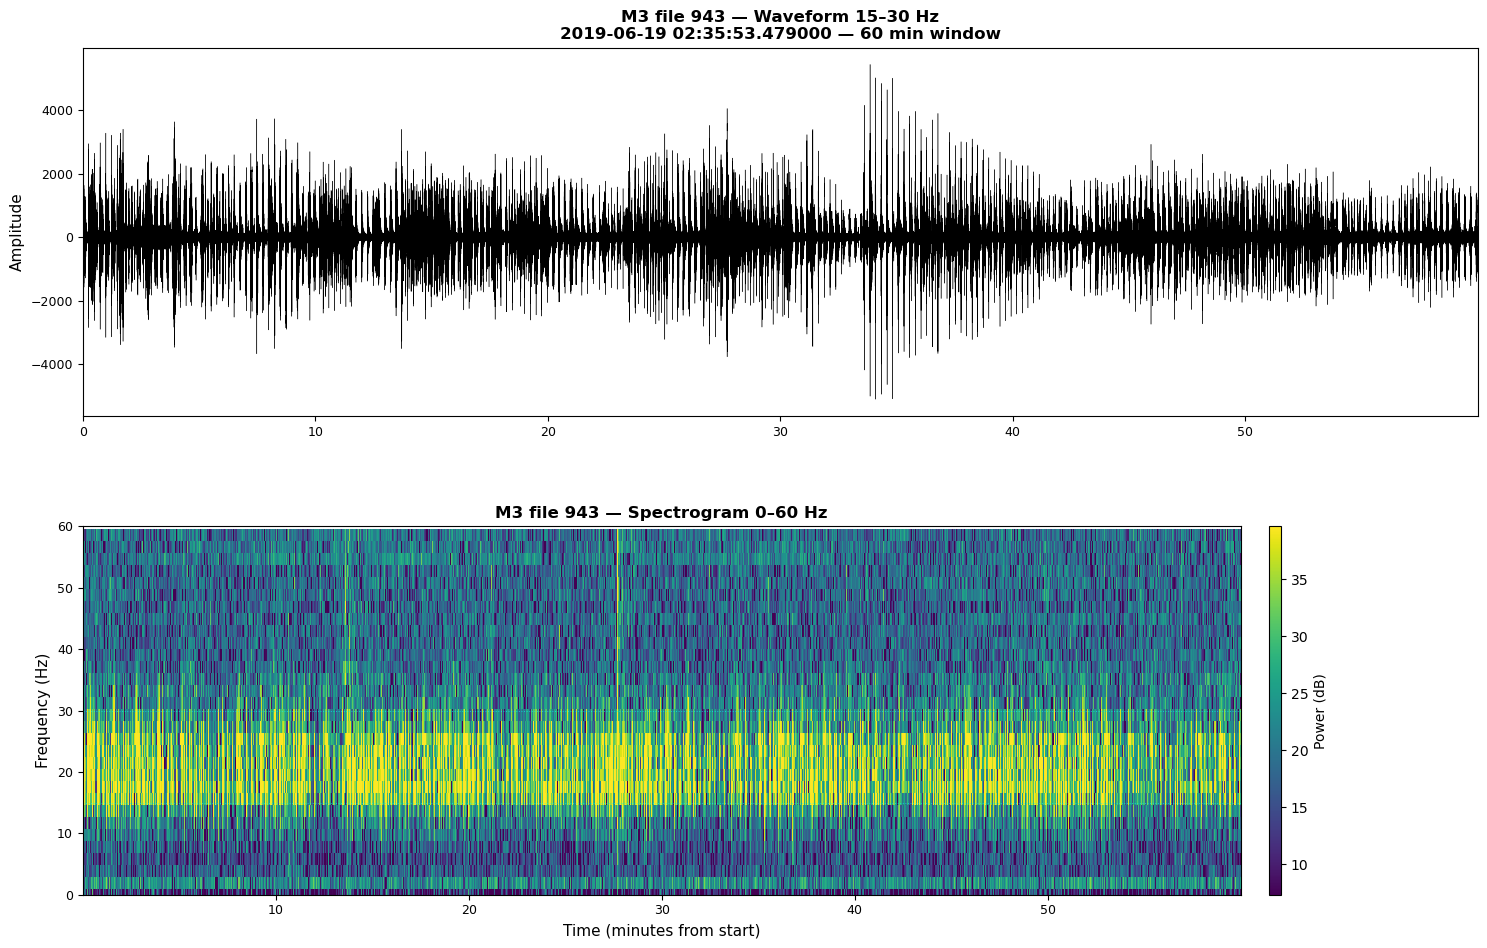

In [2]:
fig = plot_long_spectrogram('m3', 943, start_min=0, duration_min=60,
                            freq_max=60, bandpass_range=(15, 30))

### Mooring M3 — file 943 — second hour

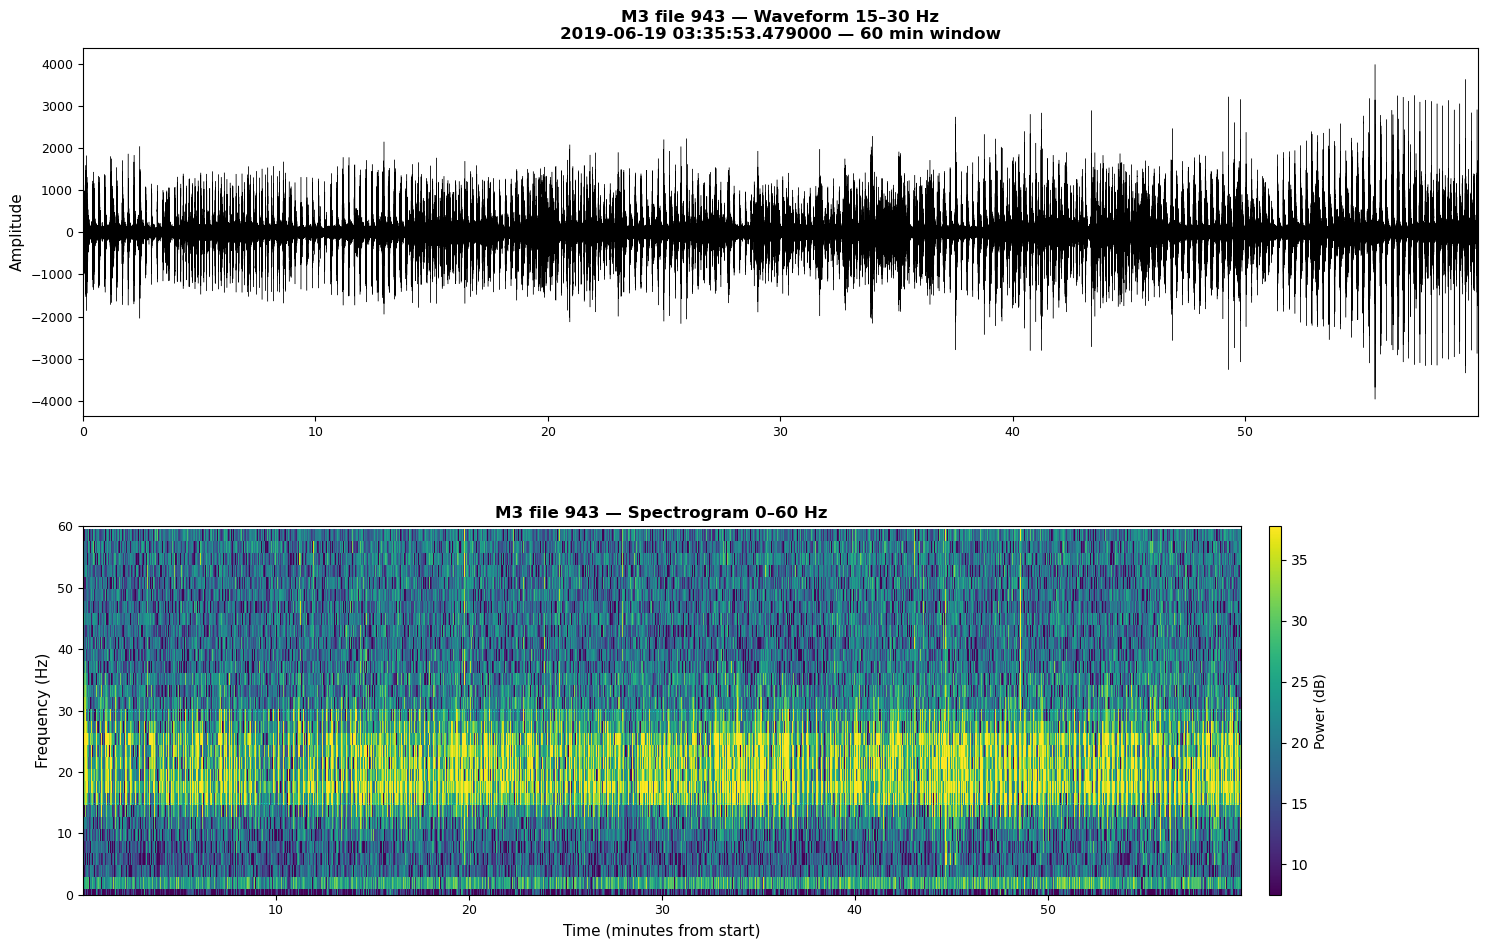

In [3]:
fig = plot_long_spectrogram('m3', 943, start_min=60, duration_min=60,
                            freq_max=60, bandpass_range=(15, 30))

### Mooring M5 — file 943 (source of panels 4, 7–10)

Same file, different mooring — is the signal also present here?

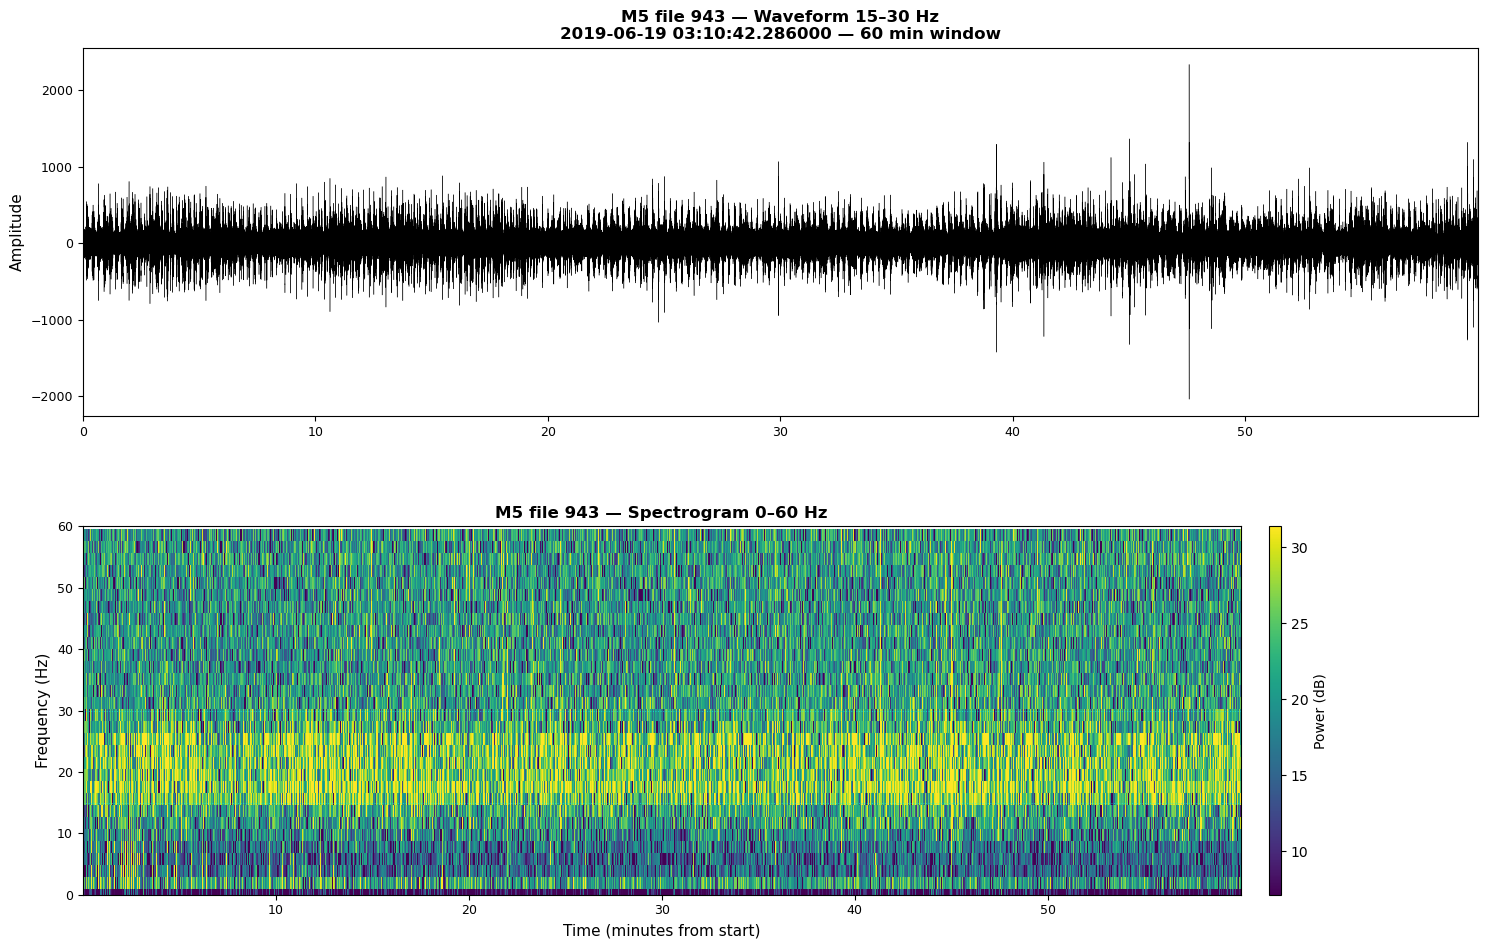

In [4]:
fig = plot_long_spectrogram('m5', 943, start_min=0, duration_min=60,
                            freq_max=60, bandpass_range=(15, 30))

### Mooring M1 — file 943 (source of panel 1)

Third mooring for comparison.

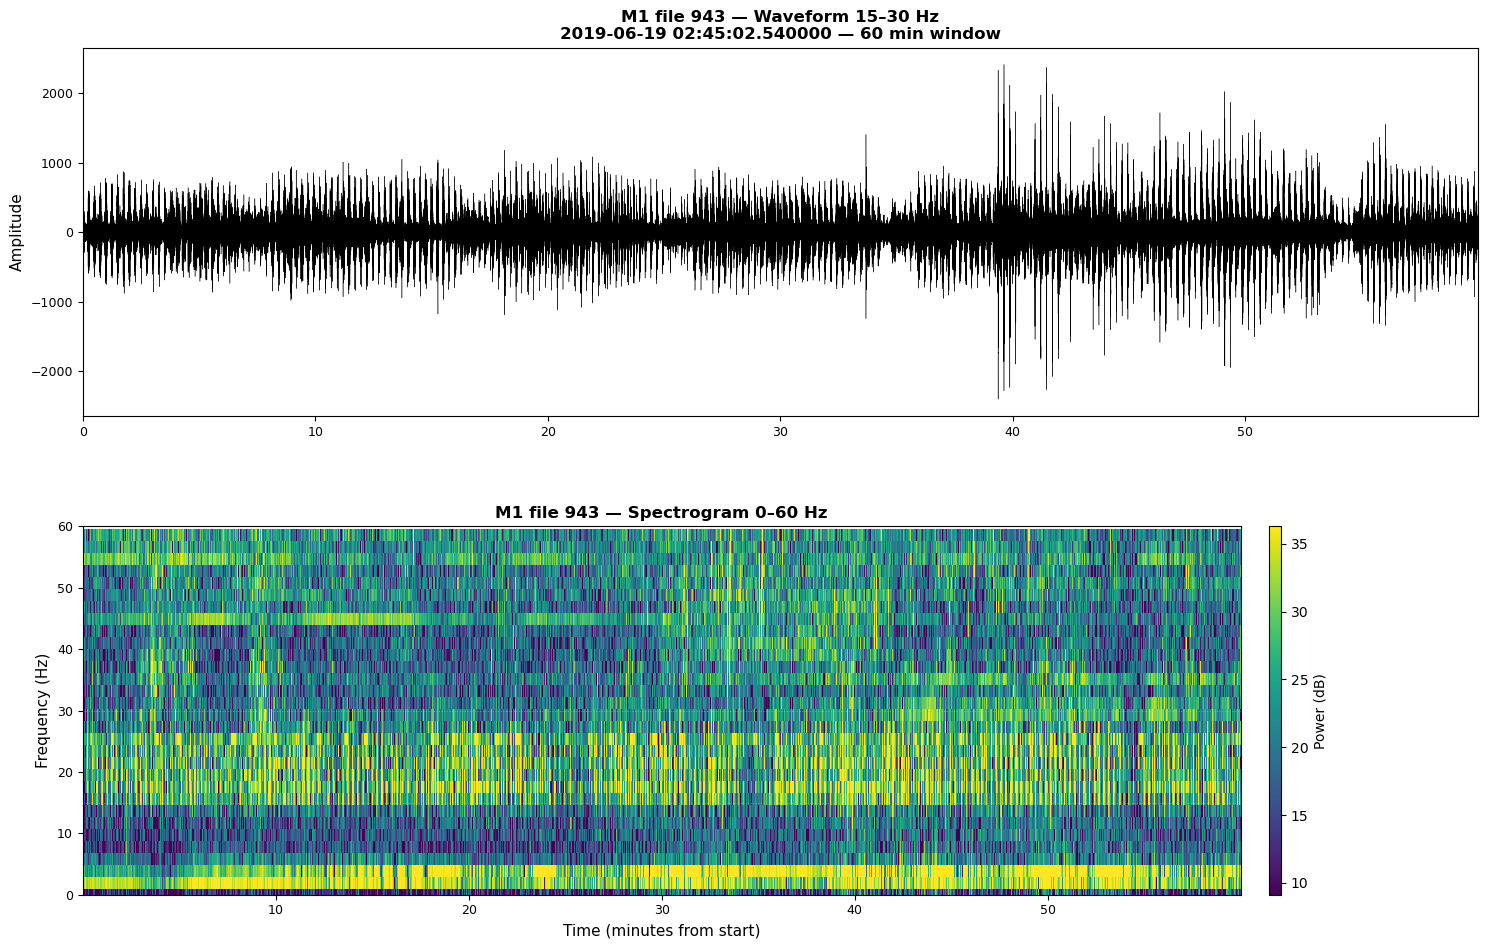

In [5]:
fig = plot_long_spectrogram('m1', 943, start_min=0, duration_min=60,
                            freq_max=60, bandpass_range=(15, 30))

---

## Observations

**Signal characteristics:**  


**Duration in record:**  


**Present on multiple moorings?**  


**Preliminary identification:**  
